# Általános Qiskit információk
A demonstrációhoz a Qiskit python-os könyvtárat és a Jupyter Notebook környezetet használom. Ha valaki saját gépen szeretné követni az anyagot, akkor fel kell telepíteni a Python-t, a Jupyter-t és a Qiskit-et. Az utolsó kettőt pip segítségével a következő módon lehet telepíteni egy már működő python installációhoz:

    pip install notebook
    pip install qiskit[visualization]
    pip install qiskit-ibm-runtime
    pip install qiskit-aer
Ezután indítható el a Jupyter a "jupyter notebook" paranccsal.

# Bloch gömb Qiskit példa 

## 1. Bloch gömb rajzolása állapotvektor alapján

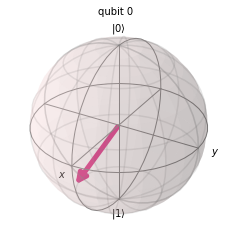

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np

#state = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
state = Statevector([0.6, 0.8])
plot_bloch_multivector(state)


## 2. Egyszerű kvantumhálózat készítése és kapuk alkalmazása

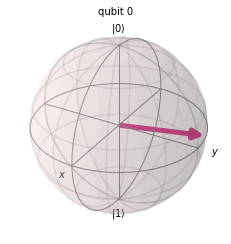

In [3]:

qc = QuantumCircuit(1,1) # 1 kvantum és 1 klasszikus bit (1 klasszikus bit a későbbi mérési eredmények tárolására kell)
qc.initialize([0.8, 0.6j], 0) #kezdeti állapot beállítása

#kvantumkapuk alkalmazása ()
qc.x(0) # Pauli X kapu
qc.y(0) # Pauli Y kapu
qc.z(0) # Pauli Z kapu
qc.h(0) # H kapu
#fázisforgató kapu
theta = np.pi
qc.p(theta, 0)
state = Statevector(qc)
plot_bloch_multivector(state)


## 3.mérés definiálása

In [3]:


qc.measure(range(1),range(1)) #mely qubiteken végezzünk mérést és azok eredményeit hova írjuk
qc.draw() #ellenőrzésként a hálózat lerajzoltatható

┌──────────────────────┐┌───┐┌───┐┌───┐┌───┐┌──────┐┌─┐
  q: ┤ Initialize(0.8,0.6j) ├┤ X ├┤ Y ├┤ Z ├┤ H ├┤ P(π) ├┤M├
     └──────────────────────┘└───┘└───┘└───┘└───┘└──────┘└╥┘
c: 1/═════════════════════════════════════════════════════╩═
                                                          0

### Mérési eredmények szimulációja

In [4]:
from qiskit_aer import Aer
from qiskit import transpile

#szimulátor kijelölése
backend = Aer.get_backend('qasm_simulator')
job_sim = backend.run(transpile(qc, backend), shots=1000) # 1000-szer ismételjük meg a kísérletet, hogy statisztikát kapjunk és elvégezzük a mérést

result_sim = job_sim.result() 

counts = result_sim.get_counts()
print(counts) #mérési eredmények kiírása

{'1': 481, '0': 519}


### Mérési eredmények vizualizációja

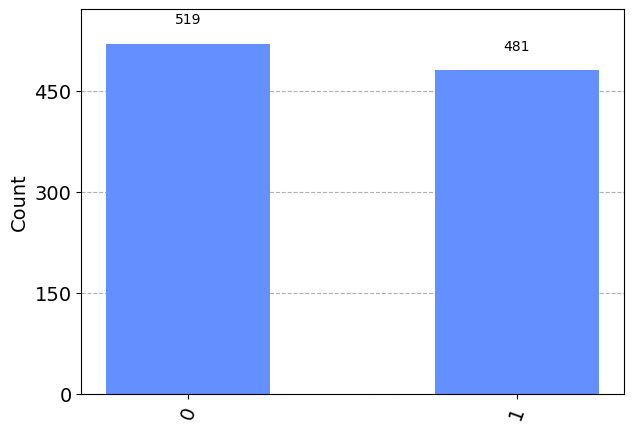

In [5]:
from qiskit.visualization import plot_histogram

#hisztogram a mérési eredményekből
plot_histogram(counts)